# Checking out the (possibly) most promising dataset

... though that _possibly_ is yet to be confirmed:
- there are no road annotations
- would need to crop large tiles and curate appropriately
- and found some irregularities in the data..?

Still, it has uniform ground resolution, a lot of images, and bounding boxes which make sampling (and transforms) relatively easy.


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geometry as sgeo

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView/train_images-subset/'
label_file = '../data/xView/xView_train.geojson'
labelnames_file = '../data/xView/xView_labelnames.pickle'

In [4]:
labelnames_di = sdut.to_from_pickle( labelnames_file)
labelnames_di.values()

dict_values(['Fixed-wing Aircraft', 'Small Aircraft', 'Passenger/Cargo Plane', 'Helicopter', 'Passenger Vehicle', 'Small Car', 'Bus', 'Pickup Truck', 'Utility Truck', 'Truck', 'Cargo Truck', 'Truck Tractor w/ Box Trailer', 'Truck Tractor', 'Trailer', 'Truck Tractor w/ Flatbed Trailer', 'Truck Tractor w/ Liquid Tank', 'Crane Truck', 'Railway Vehicle', 'Passenger Car', 'Cargo/Container Car', 'Flat Car', 'Tank car', 'Locomotive', 'Maritime Vessel', 'Motorboat', 'Sailboat', 'Tugboat', 'Barge', 'Fishing Vessel', 'Ferry', 'Yacht', 'Container Ship', 'Oil Tanker', 'Engineering Vehicle', 'Tower crane', 'Container Crane', 'Reach Stacker', 'Straddle Carrier', 'Mobile Crane', 'Dump Truck', 'Haul Truck', 'Scraper/Tractor', 'Front loader/Bulldozer', 'Excavator', 'Cement Mixer', 'Ground Grader', 'Hut/Tent', 'Shed', 'Building', 'Aircraft Hangar', 'Damaged Building', 'Facility', 'Construction Site', 'Vehicle Lot', 'Helipad', 'Storage Tank', 'Shipping container lot', 'Shipping Container', 'Pylon', 'Towe

In [102]:
def plot_object_in_context( bbox_np, category, image_):
    xmax, ymax, _ = image_.shape
    if min( bbox_np) < 0 or max(bbox_np) > min([xmax,ymax]):
        print(min( bbox_np),max(bbox_np),min([xmax,ymax]))
        return
    res_out = max( sgeo.get_dims( bbox_np)) + 64
    image_bbox_np, bbox_inner_np = sgeo.center_on_bbox( bbox_np,  max( 128, res_out), xmax, ymax, fix_edge= True)
    if image_bbox_np is not None:
        ax = splo.plot_single( sgeo.crop_to_bbox( image_, image_bbox_np), figsize= (3,3))
        splo.plot_bbox( *sgeo.bbox_np( bbox_inner_np), ax= ax)
        ax.set_title( category)
        return 

## Inital check-out of the data structure


In [12]:
df = sdut.parse_xView_geojson( label_file, labelnames_file)
df.head(3)

,cat_id,index_right,image_id,feature_id,bbox,cat,bbox_np,feature_area,building_flag,car_flag,bus_truck_flag
0,73,2356,2355.tif,374410,"[2712, 1145, 2746, 1177]",Building,"(1145, 2712, 1177, 2746)",1088,1,0,0
1,73,2356,2355.tif,394393,"[2720, 2233, 2760, 2288]",Building,"(2233, 2720, 2288, 2760)",2200,1,0,0
2,73,2356,2355.tif,374031,"[2687, 1338, 2740, 1399]",Building,"(1338, 2687, 1399, 2740)",3233,1,0,0


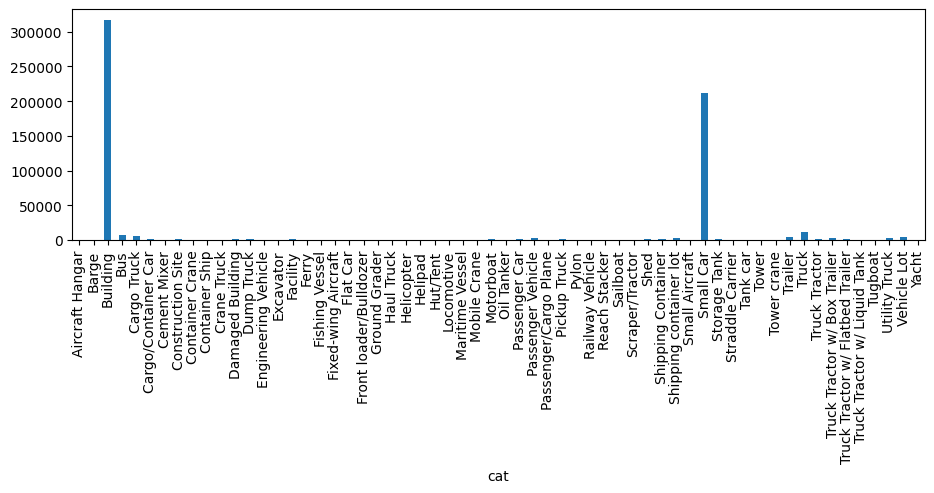

In [14]:
plt.subplots( figsize= (11,3))
_ = df.groupby('cat').count()['cat_id'].plot(kind='bar')

In [29]:
dfg = df.groupby('image_id').agg({
    'cat_id': [ len, lambda x: len(set(x)), 
                lambda x: len([y for y in x if y in sdut.xView_car_set]),
                lambda x: len([y for y in x if y in sdut.xView_bus_truck_set]),
                lambda x: len([y for y in x if y == 73])]
}).droplevel(level=0,axis=1).rename( 
    columns= {'<lambda_0>': 'n_cats', 'len': 'n_labels', '<lambda_1>':'n_cars', '<lambda_2>':'n_bus_trucks', '<lambda_3>':'n_buildings'}
)
dfg.head(3)

,n_labels,n_cats,n_cars,n_bus_trucks,n_buildings
image_id,,,,,
10.tif,63,7,2,1,44
100.tif,135,3,62,7,66
102.tif,1965,9,346,25,1563


In [186]:
start = tm.time()
for item in dfg.index[:15]:
    try:
        image_ = sdut.to_numpy( sdut.load_image( f'{data_path}{item}'))
        dfg.loc[ item, ['dims','mean','var']] = str(image_.shape), image_.mean(), image_.var()
    except FileNotFoundError:
        print( f'{item} is missing...')
print(f'Took {(tm.time()-start)/60} mins')

10.tif is missing...
100.tif is missing...
1036.tif is missing...
Took 0.08085707426071168 mins


In [187]:
dfg.head(3)

,n_labels,n_cats,n_cars,n_bus_trucks,n_buildings,dims,mean,var
image_id,,,,,,,,
10.tif,63,7,2,1,44,NaN,NaN,NaN
100.tif,135,3,62,7,66,NaN,NaN,NaN
102.tif,1965,9,346,25,1563,"(2713, 3378, 3)",50.468606,1424.313781


<BarContainer object of 847 artists>

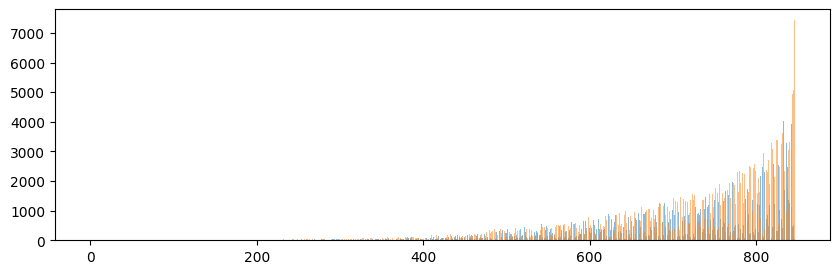

In [17]:
plt.subplots( figsize= (10,3))
#plt.bar(range(len(dfg)),dfg.sort_values(by='n_labels')['n_labels'], alpha= 0.5)
plt.bar(range(len(dfg)),dfg.sort_values(by='n_labels')['n_cars'], alpha= 0.5)
plt.bar(range(len(dfg)),dfg.sort_values(by='n_labels')['n_buildings'], alpha= 0.5)

In [188]:
target_ims = dfg.loc[ dfg['n_cars']>=200].index.tolist()
target_ims = [x for x in target_ims if os.path.exists(f'{data_path}{x}')]
print(f'{len(target_ims)} images')

228 images


In [189]:
sample_im_name = '1175.tif'#target_ims[11]
df_ = df.loc[ df['image_id']== sample_im_name]
image_ = sdut.to_numpy( sdut.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape
figsize = ( int(xmax / 200), int( ymax/ 200))
sample_im_name

'1175.tif'

In [190]:
df_.cat.unique()

array(['Truck', 'Facility', 'Damaged Building', 'Building',
       'Shipping container lot', 'Storage Tank', 'Trailer', 'Small Car',
       'Bus', 'Utility Truck', 'Cargo Truck', 'Pickup Truck',
       'Truck Tractor', 'Shed', 'Hut/Tent', 'Vehicle Lot', 'Tower',
       'Truck Tractor w/ Flatbed Trailer', 'Dump Truck', 'Excavator',
       'Ground Grader', 'Front loader/Bulldozer',
       'Truck Tractor w/ Box Trailer', 'Construction Site'], dtype=object)

In [191]:
idx_ = df_.loc[ df_['cat'] == 'Shipping container lot'].index

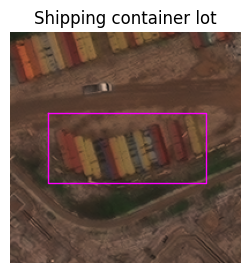

In [192]:
bbox_np, category = df_.loc[ idx_[3]][['bbox_np','cat']]
plot_object_in_context( bbox_np, category, image_)

In [193]:
idx_ = df_.loc[ (df_.car_flag==1 ) & (df_.feature_area < 80)].index

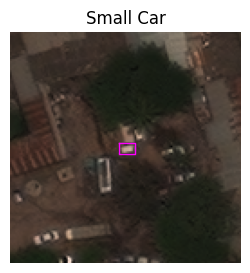

In [194]:
bbox_np, category = df_.loc[ idx_[6]][['bbox_np','cat']]
plot_object_in_context( bbox_np, category, image_)

In [195]:
idx_ = df_.loc[ (df_.car_flag==1 ) & (df_.feature_area > 120)].index

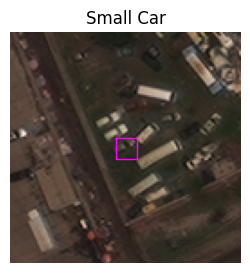

In [196]:
bbox_np, category = df_.loc[ idx_[9]][['bbox_np','cat']]
plot_object_in_context( bbox_np, category, image_)

In [198]:
car_idx_ = df_.loc[ df_.car_flag == 1].index

df_['bbox_var'] = np.nan
for ii in car_idx_:
    object_ar = sgeo.crop_to_bbox( image_, df_.loc[ ii]['bbox_np'])
    df_.loc[ ii, 'bbox_var'] = object_ar.var()

C:\Users\daago\AppData\Local\Temp\ipykernel_13288\1132708982.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['bbox_var'] = np.nan


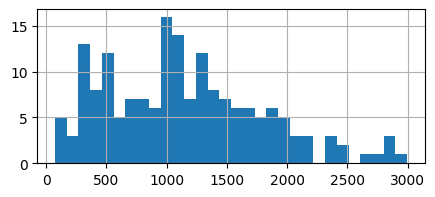

In [199]:
plt.subplots( figsize= (5,2))
_ = df_.loc[idx_, 'bbox_var'].hist(bins=30)

In [200]:
idx_bad = df_.loc[ df_.bbox_var < 200].index

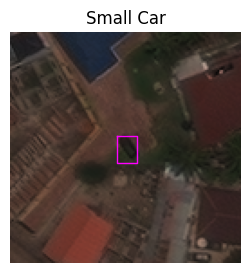

In [201]:
bbox_np, category = df_.loc[ idx_bad[2]][['bbox_np','cat']]
plot_object_in_context( bbox_np, category, image_)

In [202]:
idx_good = df_.loc[ df_.bbox_var > 300].index

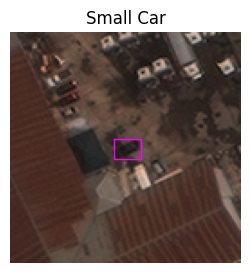

In [203]:
bbox_np, category = df_.loc[ idx_good[16]][['bbox_np','cat']]
plot_object_in_context( bbox_np, category, image_)

In [24]:
sample_im_name = '2355.tif'
df_ = df.loc[ df['image_id']== sample_im_name]
image_ = sdut.to_numpy( sdut.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape
figsize = ( int(xmax / 200), int( ymax/ 200))
sample_im_name

'2355.tif'

In [29]:
df_.cat.unique()

array(['Building', 'Small Car', 'Vehicle Lot', 'Utility Truck',
       'Facility', 'Bus', 'Pickup Truck', 'Truck Tractor w/ Box Trailer',
       'Cargo Truck', 'Truck Tractor', 'Trailer', 'Dump Truck',
       'Small Aircraft', 'Excavator', 'Truck Tractor w/ Flatbed Trailer',
       'Shipping container lot'], dtype=object)

<Axes: >

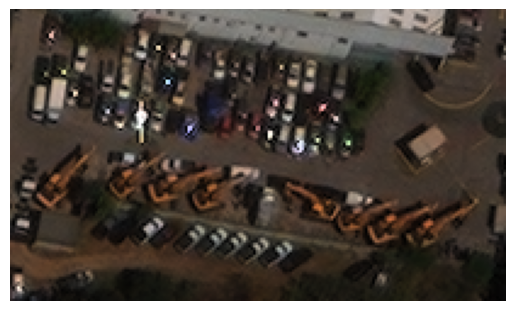

In [28]:
bbox_np = sgut.bbox_np( df_.loc[ df_['cat'] == 'Vehicle Lot'].iloc[1]['bbox'])
splo.plot_single( sgut.crop_to_bbox( image_, bbox_np))